# morphofit example usage notebook

In this notebook, we provide examples on how to run morphofit on a set of two simulated HST images mimicking the MACS J1149.5+2223 observational conditions in the Frontier Fields survey in the F814W and F160W wavebands.

morphofit is designed to be ran via command-line using esub-epipe. It can also be run in a notebook either by calling the scripts in the `main_functions` folder with `subprocess` or by calling the individual functions or the main function of the scripts in the notebook cells.

In order to run it, the user should create a folder named as the `target_name`, e.g. macs1149. All initial and produced data are going to be stored in this folder. The user should also rename images following the naming convention:

`telescopename_targetname_waveband_imagetype.fits`

e.g. HST_macs1149_f814_drz.fit

See the folder `demo_data` for an example.

__The example commands on how to run the morphofit modules in the terminal are stored in the `pipeline.yaml` file in the `main_functions` folder__

In [14]:
import os
import sys
import json
import shutil
import subprocess
from pathlib import Path

import numpy as np

from tqdm.auto import tqdm

from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.table import Table, Column

from matplotlib import pyplot as plt
from matplotlib import patches


esub_path = shutil.which("esub")

# Path where main functions are stored. It usually is the local
# git clone repo used to install Morphofit
morphofit_dir = Path.home().absolute() / "morphofit-daddona"

main_functions_dir = morphofit_dir / "main_functions"

# Path to SExtractor executable (user-dependent)
sextractor_binary_path = Path(shutil.which("sex"))
if not sextractor_binary_path.is_file():
    print("WARINING: Sextractor executable not found!")

# Path to Galfit executable (user-dependent)
galfit_binary_path = Path(shutil.which("galfit"))
if not sextractor_binary_path.is_file():
    print("WARINING: Galfit executable not found!")

# Path to root folder where data are stored and where code is run
# This should be and absolute path
root_path = Path('./demo_data/').absolute()

# Path to folder storing SExtractor required files.
# This should be an absolute path
sextractor_resources_path = morphofit_dir / 'morphofit/res/sextractor/' 

# Path to folder where the hdf5 table with parameters relevant for 
# morphofit are stored
h5pytable_folder = root_path / 'h5table'

# Name of the telescope/instrument/survey data used
telescope_name = 'HST'

# Name of the target to analyse, it has to be the same as targetname
target_field_names = 'macs1149'

# Directory where photometry catalogues are saved
target_root_path = root_path / target_field_names

# It has to be the same as imagetype.fits and represent the suffix with which 
# we define the science image
sci_images_suffix = 'drz.fits' 

# It has to be the same as imagetype.fits and represent the suffix with which 
# we define the root mean square image, if unavailable set it to 'None'
rms_images_suffix = 'rms.fits' 

# it has to be the same as imagetype.fits and represent the suffix with which
# we define the exposure time image, if unavailable set it to 'None'
exp_images_suffix = 'exp.fits' 

seg_images_suffix = 'drz.forced_seg.fits'

# pixel scale in arcsec/pixel
pixel_scale = 0.060

# Path to star catalogues folder, a first guess for the star catalogue should
# be provided by the user
star_catalogues_path = root_path / 'star_catalogues'

# suffix of the fits table storing the star positions in the image
init_ext_star_cat_suffix = 'star_positions.fits'


# same as those defined when running SExtractor
phot_apertures='3,5,8,10,13,15,18,20,23,25,28,30'

### How to use morphofit to run SExtractor in forced photometry mode on all provided images in all wavebands

SExtractor does not come pre-packaged with _morphofit_, but it needs to be installed separately.

One way to do this is by using _brew_ https://formulae.brew.sh/formula/sextractor

In [2]:
# Whether to run the script in serial (run) or in parallel (run-tasks, run-mpi)
mode = 'run-tasks'

# Total number of jobs to run, e.g. '0>3' is the syntax for running SExtractor on
# three different galaxy clusters. Since we have one cluster example, tasks is just 0>1
# in the case of galfit fit on stamps, the number of tasks is given by 
# n_target_galaxies * n_bands * n_combinations_background_sigmaimage_psf
tasks = '0>1' 

# String of comma-separated waveband names
wavebands_list = 'F814W,F160W' 

# Filename prefix of hdf5 table storing parameters relevant for morphofit
h5pytable_prefix = 'sextractor_run_table' 

# Filename prefix of the generated tar file containing images
image_archive_prefix = 'images'

# Filename prefix of the generated tar file containing res files
resources_archive_prefix = 'res_sextractor_files' 

# Pixel scale in arcsec/pixel
pixel_scale = 0.060 

# Initial guesses for the seeing FWHM in arcsec, e.g. 0.1 arcsec for HST
psf_fwhm_init_guesses = '0.1,0.1' 

# From detect_minarea to sextractor_checkimages_endings, the parameters
# have the same meaning of the corresponding SExtractor ones

# It can be all, main, check_missing and merge
function = 'all' 

# Number of available CPU for parallel computing
n_cores = os.cpu_count()

subprocess.run([
    f'{esub_path}',
    main_functions_dir / 'create_table_for_sextractor.py',
    f'--mode={mode}', 
    f'--tasks={tasks}',
    f'--root_path={root_path}',
    f'--wavebands_list={wavebands_list}',
    f'--h5pytable_folder={h5pytable_folder}',
    f'--h5pytable_prefix={h5pytable_prefix}',
    f'--telescope_name={telescope_name}',
    f'--target_field_names={target_field_names}',
    f'--sci_images_suffix={sci_images_suffix}',
    f'--rms_images_suffix={rms_images_suffix}',
    f'--exp_images_suffix={exp_images_suffix}',
    f'--ext_star_cat_suffix={init_ext_star_cat_suffix}',
    f'--image_archive_prefix={image_archive_prefix}',
    f'--resources_archive_prefix={resources_archive_prefix}',
    f'--star_catalogues_path={star_catalogues_path}',
    f'--pixel_scale={pixel_scale}',
    f'--psf_fwhm_init_guesses={psf_fwhm_init_guesses}',
    '--detect_minarea=10',
    '--detect_thresh=1.0',
    '--analysis_thresh=1.5',
    '--deblend_nthresh=64',
    '--deblend_mincont=0.0001',
    f'--phot_apertures={phot_apertures}',
    '--phot_autoparams=2.5,3.5',
    '--phot_petroparams=2.0,3.5',
    '--phot_autoapers=0.0,0.0',
    '--phot_fluxfrac=0.5',
    '--back_size=64',
    '--back_filtersize=3',
    f'--sextractor_binary_filename={sextractor_binary_path}',
    '--sextractor_config_filename=default.sex',
    '--sextractor_params_filename=default.param',
    '--sextractor_filter_filename=gauss_3.0_5x5.conv',
    '--sextractor_nnw_filename=default.nnw',
    '--sextractor_checkimages=SEGMENTATION',
    '--sextractor_checkimages_endings=seg',
    f'--sextractor_resources_path={sextractor_resources_path}',
    f'--function={function}',
    f'--n_cores={n_cores}'
])


/home/daddona/venvs/morphofit/lib/python3.14/site-packages/ekit/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


2026-05-25 10:11:02,494 -      esub.py: 435 - WARNING - DEPRECATION WARNING: The n_cores option will be dropped in a future version. Use n_jobs instead.
 
                   ______   
________________  ____  /_  
_  _ \_  ___/  / / /_  __ \ 
/  __/(__  )/ /_/ /_  /_/ / 
\___//____/ \__,_/ /_.___/  
 
2026-05-25 10:11:02,494 -      esub.py: 518 -    INFO - Running in run mode run-tasks
2026-05-25 10:11:03,593 -      esub.py: 544 - WARNING - Did not find function watchdog in the executable. Skipping it...
2026-05-25 10:11:03,593 -      esub.py: 555 -    INFO - Running setup function from executable
2026-05-25 10:11:03,593 -      esub.py: 632 -    INFO - Running locally!
2026-05-25 10:11:03,593 -      esub.py: 646 -    INFO - Running on tasks: [0]
2026-05-25 10:11:03,593 -      esub.py: 650 -    INFO - Running function main
2026-05-25 10:11:03,593 -      esub.py: 736 -    INFO - ##################### Starting parallel tasks 0>1 #####################
2026-05-25 10:11:03,593 -     utils.py:

/home/daddona/venvs/morphofit/lib/python3.14/site-packages/ekit/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


26-05-25 10:11:06 create_tab INF   =============================== running on index=0 
HST_macs1149_F814W_drz.fits
HST_macs1149_F160W_drz.fits
HST_macs1149_F814W_rms.fits
HST_macs1149_F160W_rms.fits
HST_macs1149_F814W_exp.fits
HST_macs1149_F160W_exp.fits
default.sex
default.param
gauss_3.0_5x5.conv
default.nnw
2026-05-25 10:11:06,675 -      esub.py: 745 -    INFO - ##################### Finished Task 0 #####################
2026-05-25 10:11:06,675 -      esub.py: 650 -    INFO - Running function rerun_missing
2026-05-25 10:11:06,676 -     utils.py:1073 -    INFO - Found check_missing function in executable. Running...
26-05-25 10:11:06 create_tab INF   found missing 0 
26-05-25 10:11:06 create_tab INF   [] 
2026-05-25 10:11:06,676 -      esub.py: 686 -    INFO - All indices are finished, nothing to re-run.
2026-05-25 10:11:06,676 -      esub.py: 650 -    INFO - Running function merge
2026-05-25 10:11:06,676 -      esub.py: 662 - WARNING - The requested function merge is missing in the 

CompletedProcess(args=['/home/daddona/venvs/morphofit/bin/esub', PosixPath('/home/daddona/morphofit-daddona/main_functions/create_table_for_sextractor.py'), '--mode=run-tasks', '--tasks=0>1', '--root_path=/home/daddona/morphofit-daddona/examples/demo_data', '--wavebands_list=F814W,F160W', '--h5pytable_folder=/home/daddona/morphofit-daddona/examples/demo_data/h5table', '--h5pytable_prefix=sextractor_run_table', '--telescope_name=HST', '--target_field_names=macs1149', '--sci_images_suffix=drz.fits', '--rms_images_suffix=rms.fits', '--exp_images_suffix=exp.fits', '--ext_star_cat_suffix=star_positions.fits', '--image_archive_prefix=images', '--resources_archive_prefix=res_sextractor_files', '--star_catalogues_path=/home/daddona/morphofit-daddona/examples/demo_data/star_catalogues', '--pixel_scale=0.06', '--psf_fwhm_init_guesses=0.1,0.1', '--detect_minarea=10', '--detect_thresh=1.0', '--analysis_thresh=1.5', '--deblend_nthresh=64', '--deblend_mincont=0.0001', '--phot_apertures=3,5,8,10,13,1

In [3]:
# Temporary folders location where morphofit single core jobs are run
temp_dir_path = root_path

# It can be either local or cluster, set it to local for own machine use,
# cluster for facilities using Slurm as scheduler
local_or_cluster = 'local' 

# User-defined suffix for the single-band output SExtractor catalogue
sextractor_forced_catalogue_suffix = 'forced.cat'

# Right ascension column name to be used to match galaxies across bands
sextractor_ra_keyword = 'ALPHAWIN_J2000'

# Declination column name to be used to match galaxies across bands
sextractor_dec_keyword = 'DELTAWIN_J2000' 

# Right ascension column name to be used to find stars in images and measure 
# their profile FWHM
star_catalogue_ra_keyword = 'ALPHAWIN_J2000'

# Declination column name to be used to find stars in images and measure
# their profile FWHM
star_catalogue_dec_keyword = 'DELTAWIN_J2000' 

# Suffix of the generated detection image
detection_image_suffix = 'detection.fits'

# Suffix of the fits table storing obtained instrumental and 
# observational parameters
parameters_table_suffix = 'param_table.fits' 

# User-defined suffix for the multiband output SExtractor catalogue
multiband_catalogue_suffix = 'multiband.forced.cat'

subprocess.run([
    f'{esub_path}',
    main_functions_dir / 'main_sextractor.py',
    f'--mode={mode}', 
    f'--tasks={tasks}',
    f'--root_path={root_path}',
    f'--h5pytable_folder={h5pytable_folder}',
    f'--h5pytable_prefix={h5pytable_prefix}',
    f'--image_archive_prefix={image_archive_prefix}',
    f'--resources_archive_prefix={resources_archive_prefix}',
    f'--temp_dir_path={temp_dir_path}',
    f'--local_or_cluster={local_or_cluster}',
    f'--sextractor_forced_catalogue_suffix={sextractor_forced_catalogue_suffix}',
    '--sextractor_checkimages_endings=seg',
    f'--sextractor_ra_keyword={sextractor_ra_keyword}',
    f'--sextractor_dec_keyword={sextractor_dec_keyword}',
    f'--star_catalogue_ra_keyword={star_catalogue_ra_keyword}',
    f'--star_catalogue_dec_keyword={star_catalogue_dec_keyword}',
    f'--detection_image_suffix={detection_image_suffix}',
    f'--parameters_table_suffix={parameters_table_suffix}',
    f'--multiband_catalogue_suffix={multiband_catalogue_suffix}',
    f'--function={function}',
    f'--n_cores={n_cores}'
])

/home/daddona/venvs/morphofit/lib/python3.14/site-packages/ekit/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


2026-05-25 10:11:09,987 -      esub.py: 435 - WARNING - DEPRECATION WARNING: The n_cores option will be dropped in a future version. Use n_jobs instead.
 
                   ______   
________________  ____  /_  
_  _ \_  ___/  / / /_  __ \ 
/  __/(__  )/ /_/ /_  /_/ / 
\___//____/ \__,_/ /_.___/  
 
2026-05-25 10:11:09,987 -      esub.py: 518 -    INFO - Running in run mode run-tasks
2026-05-25 10:11:11,502 -      esub.py: 544 - WARNING - Did not find function watchdog in the executable. Skipping it...
2026-05-25 10:11:11,502 -      esub.py: 555 -    INFO - Running setup function from executable
2026-05-25 10:11:11,502 -      esub.py: 632 -    INFO - Running locally!
2026-05-25 10:11:11,502 -      esub.py: 646 -    INFO - Running on tasks: [0]
2026-05-25 10:11:11,502 -      esub.py: 650 -    INFO - Running function main
2026-05-25 10:11:11,502 -      esub.py: 736 -    INFO - ##################### Starting parallel tasks 0>1 #####################
2026-05-25 10:11:11,502 -     utils.py:

/home/daddona/venvs/morphofit/lib/python3.14/site-packages/ekit/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


26-05-25 10:11:15 main_sextr INF   =============================== running on index=0 
HST_macs1149_F814W_drz.fits
HST_macs1149_F160W_drz.fits
HST_macs1149_F814W_rms.fits
HST_macs1149_F160W_rms.fits
HST_macs1149_F814W_exp.fits
HST_macs1149_F160W_exp.fits
default.sex
default.param
gauss_3.0_5x5.conv
default.nnw
macs1149_star_positions.fits
26-05-25 10:11:15 main_sextr INF   =============================== running SE on macs1149 
26-05-25 10:11:15 main_sextr INF   =============================== get saturations 
26-05-25 10:11:15 main_sextr INF   =============================== get gains 
26-05-25 10:11:15 main_sextr INF   =============================== get exptimes 
26-05-25 10:11:15 main_sextr INF   =============================== get zeropoints 
26-05-25 10:11:15 main_sextr INF   =============================== get background 
>>>> /home/daddona/morphofit-daddona/examples/demo_data/tmp_index000000/default.sex
>>>> /home/daddona/morphofit-daddona/examples/demo_data/tmp_index000000/def

CompletedProcess(args=['/home/daddona/venvs/morphofit/bin/esub', PosixPath('/home/daddona/morphofit-daddona/main_functions/main_sextractor.py'), '--mode=run-tasks', '--tasks=0>1', '--root_path=/home/daddona/morphofit-daddona/examples/demo_data', '--h5pytable_folder=/home/daddona/morphofit-daddona/examples/demo_data/h5table', '--h5pytable_prefix=sextractor_run_table', '--image_archive_prefix=images', '--resources_archive_prefix=res_sextractor_files', '--temp_dir_path=/home/daddona/morphofit-daddona/examples/demo_data', '--local_or_cluster=local', '--sextractor_forced_catalogue_suffix=forced.cat', '--sextractor_checkimages_endings=seg', '--sextractor_ra_keyword=ALPHAWIN_J2000', '--sextractor_dec_keyword=DELTAWIN_J2000', '--star_catalogue_ra_keyword=ALPHAWIN_J2000', '--star_catalogue_dec_keyword=DELTAWIN_J2000', '--detection_image_suffix=detection.fits', '--parameters_table_suffix=param_table.fits', '--multiband_catalogue_suffix=multiband.forced.cat', '--function=all', '--n_cores=16'], re

### How to use morphofit to create PSF images

Before creating the PSF images for GALFIT, the user needs to generate a star catalogue for each waveband that needs to be fitted. One way to do this is by exploiting the _HST_macs1149_multiband.forced.cat_ to select high signal-to-noise, non-saturated, isolated stars.

In [4]:
# Run the script in serial (run) or in parallel (run-tasks, run-mpi)
mode = 'run'

tasks = '0>1'
h5pytable_prefix = 'table_psf_creation'
wavebands_list = 'F814W,F160W'

# suffix of the table containing the image parameters measured in the previous module
parameters_table_suffix = 'param_table.fits'

# filename prefix of the generated tar file containing images
image_archive_prefix = 'images_for_psf'

# filename prefix of the generated tar file containing res files
resources_archive_prefix = 'res_psf_files'

# the psf image is assumed to be squared
psf_image_size = 50

function = 'all'
n_cores = 1

subprocess.run([
    f'{esub_path}',
    main_functions_dir / 'create_table_for_psf_images_per_target_field.py',
    f'--mode={mode}', 
    f'--tasks={tasks}',
    f'--root_path={root_path}',
    f'--h5pytable_folder={h5pytable_folder}',
    f'--h5pytable_prefix={h5pytable_prefix}',
    f'--wavebands_list={wavebands_list}',
    f'--target_field_names={target_field_names}',
    f'--parameters_table_suffix={parameters_table_suffix}',
    f'--sci_images_suffix={sci_images_suffix}',
    f'--image_archive_prefix={image_archive_prefix}',
    f'--resources_archive_prefix={resources_archive_prefix}',
    f'--ext_star_cat_suffix={init_ext_star_cat_suffix}',
    f'--star_catalogues_path={star_catalogues_path}',
    f'--psf_image_size={psf_image_size}',
    f'--pixel_scale={pixel_scale}',
    f'--function={function}',
    f'--n_cores={n_cores}'
])

/home/daddona/venvs/morphofit/lib/python3.14/site-packages/ekit/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


2026-05-25 10:11:17,545 -      esub.py: 435 - WARNING - DEPRECATION WARNING: The n_cores option will be dropped in a future version. Use n_jobs instead.
 
                   ______   
________________  ____  /_  
_  _ \_  ___/  / / /_  __ \ 
/  __/(__  )/ /_/ /_  /_/ / 
\___//____/ \__,_/ /_.___/  
 
2026-05-25 10:11:17,545 -      esub.py: 518 -    INFO - Running in run mode run
2026-05-25 10:11:18,691 -      esub.py: 544 - WARNING - Did not find function watchdog in the executable. Skipping it...
2026-05-25 10:11:18,691 -      esub.py: 555 -    INFO - Running setup function from executable
2026-05-25 10:11:18,691 -      esub.py: 632 -    INFO - Running locally!
2026-05-25 10:11:18,691 -      esub.py: 646 -    INFO - Running on tasks: [0]
2026-05-25 10:11:18,691 -      esub.py: 650 -    INFO - Running function main
26-05-25 10:11:18 create_tab INF   =============================== running on index=0 
HST_macs1149_F814W_drz.fits
HST_macs1149_F160W_drz.fits
macs1149_F814W_star_positions.

CompletedProcess(args=['/home/daddona/venvs/morphofit/bin/esub', PosixPath('/home/daddona/morphofit-daddona/main_functions/create_table_for_psf_images_per_target_field.py'), '--mode=run', '--tasks=0>1', '--root_path=/home/daddona/morphofit-daddona/examples/demo_data', '--h5pytable_folder=/home/daddona/morphofit-daddona/examples/demo_data/h5table', '--h5pytable_prefix=table_psf_creation', '--wavebands_list=F814W,F160W', '--target_field_names=macs1149', '--parameters_table_suffix=param_table.fits', '--sci_images_suffix=drz.fits', '--image_archive_prefix=images_for_psf', '--resources_archive_prefix=res_psf_files', '--ext_star_cat_suffix=star_positions.fits', '--star_catalogues_path=/home/daddona/morphofit-daddona/examples/demo_data/star_catalogues', '--psf_image_size=50', '--pixel_scale=0.06', '--function=all', '--n_cores=1'], returncode=0)

In [5]:
# Run the script in serial (run) or in parallel (run-tasks, run-mpi)
mode = 'run-tasks'

# total number of jobs to run, e.g. '0>3' is the syntax for running
# the PSF estimation on three different galaxy clusters. Since we
# have one cluster example, tasks is just 0>1
tasks = '0>1' 

temp_dir_path = root_path

# filename prefix of the generated tar file containing images
image_archive_prefix = 'images_for_psf'

 # filename prefix of the generated tar file containing res files
resources_archive_prefix = 'res_psf_files'

local_or_cluster = 'local'

# types of psf estimation methods, available are moffat, observed,
# pca, effective (HST only)
psf_methods = 'moffat,observed,pca' 

 # x keyword in the star catalogue containing the stars pixel positions
star_catalogue_x_keyword = 'XWIN_IMAGE_F814W'

# y keyword in the star catalogue containing the stars pixel positions
star_catalogue_y_keyword = 'YWIN_IMAGE_F814W'

function = 'all'
n_cores = 1

subprocess.run([
    f'{esub_path}',
    main_functions_dir / 'main_create_psf_images_per_target_field.py',
    f'--mode={mode}', 
    f'--tasks={tasks}',
    f'--h5pytable_folder={h5pytable_folder}',
    f'--h5pytable_prefix={h5pytable_prefix}',
    f'--temp_dir_path={temp_dir_path}',
    f'--image_archive_prefix={image_archive_prefix}',
    f'--resources_archive_prefix={resources_archive_prefix}',
    f'--local_or_cluster={local_or_cluster}',
    f'--psf_methods={psf_methods}',
    f'--star_catalogue_x_keyword={star_catalogue_x_keyword}',
    f'--star_catalogue_y_keyword={star_catalogue_y_keyword}',
    f'--function={function}',
    f'--n_cores={n_cores}'
])

/home/daddona/venvs/morphofit/lib/python3.14/site-packages/ekit/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


2026-05-25 10:11:20,218 -      esub.py: 435 - WARNING - DEPRECATION WARNING: The n_cores option will be dropped in a future version. Use n_jobs instead.
 
                   ______   
________________  ____  /_  
_  _ \_  ___/  / / /_  __ \ 
/  __/(__  )/ /_/ /_  /_/ / 
\___//____/ \__,_/ /_.___/  
 
2026-05-25 10:11:20,218 -      esub.py: 518 -    INFO - Running in run mode run-tasks
2026-05-25 10:11:21,642 -      esub.py: 544 - WARNING - Did not find function watchdog in the executable. Skipping it...
2026-05-25 10:11:21,643 -      esub.py: 555 -    INFO - Running setup function from executable
2026-05-25 10:11:21,643 -      esub.py: 632 -    INFO - Running locally!
2026-05-25 10:11:21,643 -      esub.py: 646 -    INFO - Running on tasks: [0]
2026-05-25 10:11:21,643 -      esub.py: 650 -    INFO - Running function main
2026-05-25 10:11:21,643 -      esub.py: 736 -    INFO - ##################### Starting parallel tasks 0>1 #####################
2026-05-25 10:11:21,643 -     utils.py:

/home/daddona/venvs/morphofit/lib/python3.14/site-packages/ekit/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


26-05-25 10:11:23 main_creat INF   =============================== running on index=0 
HST_macs1149_F814W_drz.fits
HST_macs1149_F160W_drz.fits
macs1149_F814W_star_positions.fits
macs1149_F160W_star_positions.fits
macs1149_param_table.fits
26-05-25 10:11:23 main_creat INF   =============================== Creating Moffat PSF images 
26-05-25 10:11:23 main_creat INF   'XWIN_IMAGE_F814W' 
26-05-25 10:11:23 main_creat INF   =============================== Creating Observed PSF images 
26-05-25 10:11:23 main_creat INF   'XWIN_IMAGE_F814W' 
26-05-25 10:11:23 main_creat INF   =============================== Creating PCA PSF images 
26-05-25 10:11:23 main_creat INF   'XWIN_IMAGE_F814W' 
2026-05-25 10:11:23,268 -      esub.py: 745 -    INFO - ##################### Finished Task 0 #####################
2026-05-25 10:11:23,268 -      esub.py: 650 -    INFO - Running function rerun_missing
2026-05-25 10:11:23,268 -     utils.py:1073 -    INFO - Found check_missing function in executable. Running..

CompletedProcess(args=['/home/daddona/venvs/morphofit/bin/esub', PosixPath('/home/daddona/morphofit-daddona/main_functions/main_create_psf_images_per_target_field.py'), '--mode=run-tasks', '--tasks=0>1', '--h5pytable_folder=/home/daddona/morphofit-daddona/examples/demo_data/h5table', '--h5pytable_prefix=table_psf_creation', '--temp_dir_path=/home/daddona/morphofit-daddona/examples/demo_data', '--image_archive_prefix=images_for_psf', '--resources_archive_prefix=res_psf_files', '--local_or_cluster=local', '--psf_methods=moffat,observed,pca', '--star_catalogue_x_keyword=XWIN_IMAGE_F814W', '--star_catalogue_y_keyword=YWIN_IMAGE_F814W', '--function=all', '--n_cores=1'], returncode=0)

### How to use morphofit to run GALFIT on stamps

GALFIT does not come pre-packaged with _morphofit_, but it needs to be downloaded from https://users.obs.carnegiescience.edu/peng/work/galfit/galfit.html

This part requires a target catalogue and a sources catalogue. The former contains the information about the relevant sources for which we want to estimate the structural parameters. The latter contains all the other sources such that neighbouring objects are fitted simultaneously.

One possible selection could be to define as targets all galaxies having MAG_AUTO_f814<=22.5, while defining as sources all galaxies having 22.5<MAG_AUTO_F814W<27.

In [6]:
m1149_se_cat = Table.read(
    target_root_path / 'HST_macs1149_multiband.forced.cat'
)

target_mask = np.where(
    (m1149_se_cat['MAG_AUTO_F814W'] <= 22.5) &
    (m1149_se_cat['CLASS_STAR_F814W'] < 0.95)
)

sources_mask = np.where(
    (m1149_se_cat['MAG_AUTO_F814W'] > 22.5) & 
    (m1149_se_cat['MAG_AUTO_F814W'] < 27) &
    (m1149_se_cat['CLASS_STAR_F814W'] < 0.95)
)

# we select only one object for the sake of speed
m1149_se_cat[target_mask].write(
    target_root_path / 'HST_macs1149_multiband_targets.cat',
    format='fits',
    overwrite=True
)

m1149_se_cat[sources_mask].write(
    target_root_path / 'HST_macs1149_multiband_sources.cat',
    format='fits',
    overwrite=True
)

Once the two catalogues have been created by the user, the columns 'SERSIC_INDEX', 'TOFIT', 'LIGHT_PROFILE' and 'COMPONENT_NUMBER' needs to be appended to both catalogues:
- *SERSIC_INDEX_{}*.format(waveband), initial values of the Sersic indices for the fit with GALFIT

- *TOFIT_{}*.format(waveband),  whether we want to fit that source or keep its values fixed

- *LIGHT_PROFILE_{}*.format(waveband),  the type of light profile we would like to fit (sersic,devauc,expdisk)

- *COMPONENT_NUMBER*, the integer index denoting the specific component we are fitting to the source. If, e.g. we do a bulge plus disk decomposition, each source will have two rows in the table, one with COMPONENT_NUMBER=0 and LIGHT_PROFILE=devauc, and the other with COMPONENT_NUMBER=1 and LIGHT_PROFILE=expdisk. 

In [7]:
target_cat = Table.read(
    target_root_path / 'HST_macs1149_multiband_targets.cat',
    format='fits'
)
source_cat = Table.read(
    target_root_path / 'HST_macs1149_multiband_sources.cat',
    format='fits'
)

wavebands = ['F814W', 'F160W']

default_waveband_col_values = {
    'SERSIC_INDEX': (2.5, float),
    'TOFIT': (1, int),
    'LIGHT_PROFILE': ('sersic', 'U6'),
}

for cat in [target_cat, source_cat]:
    for waveband in wavebands:
        for col, (val, dtype) in default_waveband_col_values.items():
            cat.add_column(Column(
                np.full(len(cat), val, dtype=dtype),
                name=f'{col}_{waveband}'
            ))
            
    cat.add_column(Column(
        np.full(len(cat),0, dtype=int),
        name='COMPONENT_NUMBER'
    ))
    
target_cat.write(
    target_root_path /'HST_macs1149_multiband_targets.cat',
    format='fits',
    overwrite=True
)
source_cat.write(
    target_root_path / 'HST_macs1149_multiband_sources.cat',
    format='fits',
    overwrite=True
)

In [8]:
mode = 'run' 
tasks = '0>1'

h5pytable_filename = 'table_galfit_on_stamps_run.h5'

# types of psf estimation methods, available are moffat, observed,
# pca, effective (HST only)
psf_image_types_list='moffat_psf,observed_psf,pca_psf' 

# types of sigma image generation methods, available are 
# custom_sigma_image and internal_generated_sigma_image
sigma_image_types_list='custom_sigma_image,internal_generated_sigma_image'

# types of background estimation methods, available are
# background_free_fit and background_fixed_value
background_estimate_methods_list='background_free_fit,background_fixed_value'

# factor by which the stamp around the galaxy is enlarged as function
# of the target galaxy effective radius 
enlarging_image_factor=20 

# if a neighbouring galaxy is closer to the target than this factor times
# the target galaxy effective radius, then the neighbouring galaxy is 
# simultaneously fit
enlarging_separation_factor=10

convolution_box_size=256

source_galaxies_catalogue_suffix='multiband_sources.cat'

target_galaxies_catalogue_suffix='multiband_targets.cat'

target_galaxies_id_key='NUMBER'

parameters_table_suffix = 'param_table.fits'

function = 'main'
n_cores = 1

subprocess.run([
    f'{esub_path}',
    main_functions_dir / 'create_table_for_galfit_stamps.py',
    f'--mode={mode}', 
    f'--tasks={tasks}',
    f'--root_path={root_path}',
    f'--h5pytable_folder={h5pytable_folder}',
    f'--h5pytable_filename={h5pytable_filename}',
    f'--telescope_name={telescope_name}',
    f'--target_field_names={target_field_names}',
    f'--wavebands_list={wavebands_list}',
    f'--psf_image_types_list={psf_image_types_list}',
    f'--sigma_image_types_list={sigma_image_types_list}',
    f'--background_estimate_methods_list={background_estimate_methods_list}',
    f'--enlarging_image_factor={enlarging_image_factor}',
    f'--enlarging_separation_factor={enlarging_separation_factor}',
    f'--pixel_scale={pixel_scale}',
    f'--convolution_box_size={convolution_box_size}',
    f'--galfit_binary_file={galfit_binary_path}',
    f'--target_galaxies_catalogue_suffix={target_galaxies_catalogue_suffix}',
    f'--target_galaxies_id_key={target_galaxies_id_key}',
    f'--source_galaxies_catalogue_suffix={source_galaxies_catalogue_suffix}',
    f'--parameters_table_suffix={parameters_table_suffix}',
    f'--sci_images_suffix={sci_images_suffix}',
    f'--rms_images_suffix={rms_images_suffix}',
    f'--exp_images_suffix={exp_images_suffix}',
    f'--seg_images_suffix={seg_images_suffix}',
    f'--function={function}',
    f'--n_cores={n_cores}'
])

/home/daddona/venvs/morphofit/lib/python3.14/site-packages/ekit/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


2026-05-25 10:11:26,538 -      esub.py: 435 - WARNING - DEPRECATION WARNING: The n_cores option will be dropped in a future version. Use n_jobs instead.
 
                   ______   
________________  ____  /_  
_  _ \_  ___/  / / /_  __ \ 
/  __/(__  )/ /_/ /_  /_/ / 
\___//____/ \__,_/ /_.___/  
 
2026-05-25 10:11:26,538 -      esub.py: 518 -    INFO - Running in run mode run
2026-05-25 10:11:27,661 -      esub.py: 555 -    INFO - Running setup function from executable
2026-05-25 10:11:27,662 -      esub.py: 632 -    INFO - Running locally!
2026-05-25 10:11:27,662 -      esub.py: 646 -    INFO - Running on tasks: [0]
2026-05-25 10:11:27,662 -      esub.py: 650 -    INFO - Running function main
26-05-25 10:11:27 create_tab INF   Number of combinations: 120 
2026-05-25 10:11:27,769 -      esub.py: 709 -    INFO - ##################### Starting Task 0 #####################
2026-05-25 10:11:27,776 -      esub.py: 714 -    INFO - ##################### Finished Task 0 ####################

CompletedProcess(args=['/home/daddona/venvs/morphofit/bin/esub', PosixPath('/home/daddona/morphofit-daddona/main_functions/create_table_for_galfit_stamps.py'), '--mode=run', '--tasks=0>1', '--root_path=/home/daddona/morphofit-daddona/examples/demo_data', '--h5pytable_folder=/home/daddona/morphofit-daddona/examples/demo_data/h5table', '--h5pytable_filename=table_galfit_on_stamps_run.h5', '--telescope_name=HST', '--target_field_names=macs1149', '--wavebands_list=F814W,F160W', '--psf_image_types_list=moffat_psf,observed_psf,pca_psf', '--sigma_image_types_list=custom_sigma_image,internal_generated_sigma_image', '--background_estimate_methods_list=background_free_fit,background_fixed_value', '--enlarging_image_factor=20', '--enlarging_separation_factor=10', '--pixel_scale=0.06', '--convolution_box_size=256', '--galfit_binary_file=/usr/local/bin/galfit', '--target_galaxies_catalogue_suffix=multiband_targets.cat', '--target_galaxies_id_key=NUMBER', '--source_galaxies_catalogue_suffix=multiban

temporary directory are removed only if the code runs successfully. If there is any error, the user should manually delete the temporary directory.

The results of the fit are saved in sub-directories of the stamps directory in ./demo_data/macs1149

In [9]:
mode = 'run-tasks' 

# number of tasks is equal to the number of combinations from
# the previous cell
tasks = '0>2'

temp_dir_path = root_path

h5pytable_filename = 'table_galfit_on_stamps_run.h5'

# here we always need an absolute path
temp_dir_path = root_path.absolute()

files_archive_prefix='galfit_res'

target_galaxies_keys='NUMBER,XWIN_IMAGE_F814W,YWIN_IMAGE_F814W,ALPHAWIN_J2000_F814W,DELTAWIN_J2000_F814W,MAG_AUTO,FLUX_RADIUS,FLUX_RADIUS_F814W,SERSIC_INDEX,BWIN_IMAGE,AWIN_IMAGE,THETAWIN_SKY,TOFIT,COMPONENT_NUMBER,LIGHT_PROFILE' # keyword names in the targets catalogue for the properties needed by morphofit
source_galaxies_keys='NUMBER,ALPHAWIN_J2000_F814W,DELTAWIN_J2000_F814W,MAG_AUTO,FLUX_RADIUS,SERSIC_INDEX,BWIN_IMAGE,AWIN_IMAGE,THETAWIN_SKY,TOFIT,COMPONENT_NUMBER,LIGHT_PROFILE' # keyword names in the sources catalogue for the properties needed by morphofit

display_type_galfit='regular'

galfit_options='0'

# True to save diagnostic plots, False otherwise
diagnostic_plots='True' 

local_or_cluster='local'
function = 'main'
n_cores = os.cpu_count()

subprocess.run([
    f'{esub_path}',
    main_functions_dir / 'main_galfit_stamps.py',
    f'--mode={mode}', 
    f'--tasks={tasks}',
    f'--h5pytable_folder={h5pytable_folder}',
    f'--h5pytable_filename={h5pytable_filename}',
    f'--temp_dir_path={temp_dir_path}',
    f'--files_archive_prefix={files_archive_prefix}',
    f'--target_galaxies_keys={target_galaxies_keys}',
    f'--source_galaxies_keys={source_galaxies_keys}',
    f'--display_type_galfit={display_type_galfit}',
    f'--galfit_options={galfit_options}',
    f'--diagnostic_plots={diagnostic_plots}',
    f'--phot_apertures={phot_apertures}',
    f'--local_or_cluster={local_or_cluster}',
    f'--function={function}',
    f'--n_cores={n_cores}'
])

/home/daddona/venvs/morphofit/lib/python3.14/site-packages/ekit/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


2026-05-25 10:11:30,718 -      esub.py: 435 - WARNING - DEPRECATION WARNING: The n_cores option will be dropped in a future version. Use n_jobs instead.
 
                   ______   
________________  ____  /_  
_  _ \_  ___/  / / /_  __ \ 
/  __/(__  )/ /_/ /_  /_/ / 
\___//____/ \__,_/ /_.___/  
 
2026-05-25 10:11:30,718 -      esub.py: 518 -    INFO - Running in run mode run-tasks
2026-05-25 10:11:32,067 -      esub.py: 555 -    INFO - Running setup function from executable
2026-05-25 10:11:32,067 -      esub.py: 632 -    INFO - Running locally!
2026-05-25 10:11:32,067 -      esub.py: 646 -    INFO - Running on tasks: [0, 1]
2026-05-25 10:11:32,067 -      esub.py: 650 -    INFO - Running function main
2026-05-25 10:11:32,067 -      esub.py: 736 -    INFO - ##################### Starting parallel tasks 0>2 #####################
2026-05-25 10:11:32,067 -     utils.py:1241 - WARNING - NotImplementedWarning: Using run-tasks creates a multiprocessing worker pool with just one thread per

/home/daddona/venvs/morphofit/lib/python3.14/site-packages/ekit/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


26-05-25 10:11:35 main_galfi INF   =============================== running on index=0 (1 of 1) 
26-05-25 10:11:35 main_galfi INF   =============================== running on index=1 (1 of 1) 
HST_macs1149_F814W_drz.fits
HST_macs1149_F814W_drz.fits
HST_macs1149_F814W_drz.forced_seg.fits
HST_macs1149_F814W_drz.forced_seg.fits
HST_macs1149_multiband_targets.cat
HST_macs1149_multiband_sources.cat
HST_macs1149_multiband_targets.cat
HST_macs1149_multiband_sources.cat
HST_macs1149_F814W_drz.fits
HST_macs1149_F814W_drz.fits
HST_macs1149_F814W_drz.forced_seg.fits
HST_macs1149_F814W_drz.forced_seg.fits
HST_macs1149_multiband_targets.cat
HST_macs1149_multiband_sources.cat
HST_macs1149_F814W_rms.fits
HST_macs1149_multiband_targets.cat
HST_macs1149_multiband_sources.cat
HST_macs1149_F814W_rms.fits
HST_macs1149_F814W_exp.fits
HST_macs1149_F814W_exp.fits
26-05-25 10:11:35 main_galfi INF   =============================== macs1149, F814W, stamp 01, moffat_psf, custom_sigma_image, background_free_fit 
2

tar: moffat_psf_macs1149_F814W.fits: Cannot stat: No such file or directory
tar: Exiting with failure status due to previous errors
tar: moffat_psf_macs1149_F814W.fits: Cannot stat: No such file or directory
tar: Exiting with failure status due to previous errors


26-05-25 10:11:36 main_galfi INF   =============================== find neighbouring galaxies in stamp 
26-05-25 10:11:36 main_galfi INF   =============================== find neighbouring galaxies in stamp 
26-05-25 10:11:36 main_galfi INF   =============================== create bad pixel mask for GALFIT 
26-05-25 10:11:36 main_galfi INF   =============================== create bad pixel mask for GALFIT 
26-05-25 10:11:36 main_galfi INF   =============================== local background estimate in stamp 
26-05-25 10:11:36 main_galfi INF   =============================== local background estimate in stamp 
26-05-25 10:11:36 main_galfi INF   =============================== create sigma image for GALFIT 
26-05-25 10:11:36 main_galfi INF   =============================== create sigma image for GALFIT 
26-05-25 10:11:36 main_galfi INF   =============================== format sky subtraction for GALFIT 
26-05-25 10:11:36 main_galfi INF   =============================== format properties f

CompletedProcess(args=['/home/daddona/venvs/morphofit/bin/esub', PosixPath('/home/daddona/morphofit-daddona/main_functions/main_galfit_stamps.py'), '--mode=run-tasks', '--tasks=0>2', '--h5pytable_folder=/home/daddona/morphofit-daddona/examples/demo_data/h5table', '--h5pytable_filename=table_galfit_on_stamps_run.h5', '--temp_dir_path=/home/daddona/morphofit-daddona/examples/demo_data', '--files_archive_prefix=galfit_res', '--target_galaxies_keys=NUMBER,XWIN_IMAGE_F814W,YWIN_IMAGE_F814W,ALPHAWIN_J2000_F814W,DELTAWIN_J2000_F814W,MAG_AUTO,FLUX_RADIUS,FLUX_RADIUS_F814W,SERSIC_INDEX,BWIN_IMAGE,AWIN_IMAGE,THETAWIN_SKY,TOFIT,COMPONENT_NUMBER,LIGHT_PROFILE', '--source_galaxies_keys=NUMBER,ALPHAWIN_J2000_F814W,DELTAWIN_J2000_F814W,MAG_AUTO,FLUX_RADIUS,SERSIC_INDEX,BWIN_IMAGE,AWIN_IMAGE,THETAWIN_SKY,TOFIT,COMPONENT_NUMBER,LIGHT_PROFILE', '--display_type_galfit=regular', '--galfit_options=0', '--diagnostic_plots=True', '--phot_apertures=3,5,8,10,13,15,18,20,23,25,28,30', '--local_or_cluster=local'

### How to combine the results from multiple fit on stamps in a single catalogue

These morphofit module creates a single multiband catalogue that contains both the SExtractor and the GALFIT results. Each galaxy has best-fitting parameters from different combinations of psf, sigma image and background. This module combines them into a single weighted average estimate.

In [10]:
mode = 'run' 
tasks = '0>1'
h5pytable_filename = 'table_masterstamps.h5'
wavebands_list = 'F814W,F160W'
psf_image_types_list='moffat_psf,observed_psf,pca_psf'
sigma_image_types_list='custom_sigma_image,internal_generated_sigma_image'
background_estimate_methods_list='background_free_fit,background_fixed_value'
target_galaxies_catalogue_suffix='multiband_targets.cat'
source_galaxies_catalogue_suffix='multiband_sources.cat'
function = 'all'
n_cores = 1

subprocess.run([
    f'{esub_path}',
    main_functions_dir / 'create_table_for_masterstamps.py',
    f'--mode={mode}', 
    f'--tasks={tasks}',
    f'--root_path={root_path}',
    f'--h5pytable_folder={h5pytable_folder}',
    f'--h5pytable_filename={h5pytable_filename}',
    f'--telescope_name={telescope_name}',
    f'--target_field_names={target_field_names}',
    f'--wavebands_list={wavebands_list}',
    f'--psf_image_types_list={psf_image_types_list}',
    f'--sigma_image_types_list={sigma_image_types_list}',
    f'--background_estimate_methods_list={background_estimate_methods_list}',
    f'--target_galaxies_catalogue_suffix={target_galaxies_catalogue_suffix}',
    f'--source_galaxies_catalogue_suffix={source_galaxies_catalogue_suffix}',
    f'--function={function}',
    f'--n_cores={n_cores}'
])

/home/daddona/venvs/morphofit/lib/python3.14/site-packages/ekit/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


2026-05-25 10:12:00,173 -      esub.py: 435 - WARNING - DEPRECATION WARNING: The n_cores option will be dropped in a future version. Use n_jobs instead.
 
                   ______   
________________  ____  /_  
_  _ \_  ___/  / / /_  __ \ 
/  __/(__  )/ /_/ /_  /_/ / 
\___//____/ \__,_/ /_.___/  
 
2026-05-25 10:12:00,173 -      esub.py: 518 -    INFO - Running in run mode run
2026-05-25 10:12:01,297 -      esub.py: 544 - WARNING - Did not find function watchdog in the executable. Skipping it...
2026-05-25 10:12:01,297 -      esub.py: 555 -    INFO - Running setup function from executable
2026-05-25 10:12:01,297 -      esub.py: 632 -    INFO - Running locally!
2026-05-25 10:12:01,297 -      esub.py: 646 -    INFO - Running on tasks: [0]
2026-05-25 10:12:01,297 -      esub.py: 650 -    INFO - Running function main
2026-05-25 10:12:01,337 -      esub.py: 709 -    INFO - ##################### Starting Task 0 #####################
2026-05-25 10:12:01,338 -      esub.py: 714 -    INFO - #

CompletedProcess(args=['/home/daddona/venvs/morphofit/bin/esub', PosixPath('/home/daddona/morphofit-daddona/main_functions/create_table_for_masterstamps.py'), '--mode=run', '--tasks=0>1', '--root_path=/home/daddona/morphofit-daddona/examples/demo_data', '--h5pytable_folder=/home/daddona/morphofit-daddona/examples/demo_data/h5table', '--h5pytable_filename=table_masterstamps.h5', '--telescope_name=HST', '--target_field_names=macs1149', '--wavebands_list=F814W,F160W', '--psf_image_types_list=moffat_psf,observed_psf,pca_psf', '--sigma_image_types_list=custom_sigma_image,internal_generated_sigma_image', '--background_estimate_methods_list=background_free_fit,background_fixed_value', '--target_galaxies_catalogue_suffix=multiband_targets.cat', '--source_galaxies_catalogue_suffix=multiband_sources.cat', '--function=all', '--n_cores=1'], returncode=0)

The results of the combination is saved in ./demo_data/macs1149

In [11]:
mode = 'run-tasks' 

# number of tasks is equal to the number of target fields,
# in this case the cluster m1149
tasks = '0>1'

h5pytable_filename = 'table_masterstamps.h5'
temp_dir_path = root_path
galfit_properties_mastertable_suffix='mastertable.fits'
source_galaxies_catalogue_id_key = 'NUMBER'
galaxy_ids_key = 'NUMBER'
light_profiles_key = 'LIGHT_PROFILE'
galaxy_components_key = 'COMPONENT_NUMBER'
function = 'all'
n_cores = 1

subprocess.run([
    f'{esub_path}',
    main_functions_dir / 'main_create_masterstamps_catalogue.py',
    f'--mode={mode}',
    f'--tasks={tasks}',
    f'--h5pytable_folder={h5pytable_folder}',
    f'--h5pytable_filename={h5pytable_filename}',
    f'--temp_dir_path={galfit_properties_mastertable_suffix}'.format(temp_dir_path),
    f'--galfit_properties_mastertable_suffix={galfit_properties_mastertable_suffix}',
    f'--source_galaxies_catalogue_id_key={source_galaxies_catalogue_id_key}',
    f'--galaxy_ids_key={galaxy_ids_key}',
    f'--light_profiles_key={light_profiles_key}',
    f'--galaxy_components_key={galaxy_components_key}',
    f'--local_or_cluster={local_or_cluster}',
    f'--function={function}',
    f'--n_cores={n_cores}'
])

/home/daddona/venvs/morphofit/lib/python3.14/site-packages/ekit/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


2026-05-25 10:12:03,880 -      esub.py: 435 - WARNING - DEPRECATION WARNING: The n_cores option will be dropped in a future version. Use n_jobs instead.
 
                   ______   
________________  ____  /_  
_  _ \_  ___/  / / /_  __ \ 
/  __/(__  )/ /_/ /_  /_/ / 
\___//____/ \__,_/ /_.___/  
 
2026-05-25 10:12:03,880 -      esub.py: 518 -    INFO - Running in run mode run-tasks
2026-05-25 10:12:05,027 -      esub.py: 544 - WARNING - Did not find function watchdog in the executable. Skipping it...
2026-05-25 10:12:05,027 -      esub.py: 555 -    INFO - Running setup function from executable
2026-05-25 10:12:05,027 -      esub.py: 632 -    INFO - Running locally!
2026-05-25 10:12:05,027 -      esub.py: 646 -    INFO - Running on tasks: [0]
2026-05-25 10:12:05,027 -      esub.py: 650 -    INFO - Running function main
2026-05-25 10:12:05,027 -      esub.py: 736 -    INFO - ##################### Starting parallel tasks 0>1 #####################
2026-05-25 10:12:05,027 -     utils.py:

/home/daddona/venvs/morphofit/lib/python3.14/site-packages/ekit/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


26-05-25 10:12:06 main_creat INF   =============================== running on index=0 
26-05-25 10:12:06 main_creat INF   [Errno 2] No such file or directory: 'mastertable.fits/tmp_index000000/HST_macs1149_F814W_02_moffat_psf_custom_sigma_image_background_free_fit.fits' 
26-05-25 10:12:06 main_creat INF   Missing HST_macs1149_F814W_02_moffat_psf_custom_sigma_image_background_free_fit.fits table 
26-05-25 10:12:06 main_creat INF   [Errno 2] No such file or directory: 'mastertable.fits/tmp_index000000/HST_macs1149_F814W_03_moffat_psf_custom_sigma_image_background_free_fit.fits' 
26-05-25 10:12:06 main_creat INF   Missing HST_macs1149_F814W_03_moffat_psf_custom_sigma_image_background_free_fit.fits table 
26-05-25 10:12:06 main_creat INF   [Errno 2] No such file or directory: 'mastertable.fits/tmp_index000000/HST_macs1149_F814W_04_moffat_psf_custom_sigma_image_background_free_fit.fits' 
26-05-25 10:12:06 main_creat INF   Missing HST_macs1149_F814W_04_moffat_psf_custom_sigma_image_backgroun

cp: cannot stat '/home/daddona/morphofit-daddona/examples/demo_data/macs1149/stamps/stamp02_moffat_psf_custom_sigma_image_background_free_fit/HST_macs1149_F814W_02_moffat_psf_custom_sigma_image_background_free_fit.fits': No such file or directory
cp: cannot stat '/home/daddona/morphofit-daddona/examples/demo_data/macs1149/stamps/stamp03_moffat_psf_custom_sigma_image_background_free_fit/HST_macs1149_F814W_03_moffat_psf_custom_sigma_image_background_free_fit.fits': No such file or directory
cp: cannot stat '/home/daddona/morphofit-daddona/examples/demo_data/macs1149/stamps/stamp04_moffat_psf_custom_sigma_image_background_free_fit/HST_macs1149_F814W_04_moffat_psf_custom_sigma_image_background_free_fit.fits': No such file or directory
cp: cannot stat '/home/daddona/morphofit-daddona/examples/demo_data/macs1149/stamps/stamp00_moffat_psf_custom_sigma_image_background_free_fit/HST_macs1149_F160W_00_moffat_psf_custom_sigma_image_background_free_fit.fits': No such file or directory
cp: cannot s

26-05-25 10:12:06 catalogue_ INF   output array is read-only 
26-05-25 10:12:06 catalogue_ INF   output array is read-only 
26-05-25 10:12:06 catalogue_ INF   output array is read-only 
26-05-25 10:12:06 main_creat INF   input tables for join must both have at least one row 
26-05-25 10:12:06 main_creat INF   input tables for join must both have at least one row 
26-05-25 10:12:06 main_creat INF   input tables for join must both have at least one row 
2026-05-25 10:12:06,962 -      esub.py: 745 -    INFO - ##################### Finished Task 0 #####################
2026-05-25 10:12:06,962 -      esub.py: 650 -    INFO - Running function rerun_missing
2026-05-25 10:12:06,962 -     utils.py:1073 -    INFO - Found check_missing function in executable. Running...
1
26-05-25 10:12:07 main_creat INF   found missing 0 
26-05-25 10:12:07 main_creat INF   [] 
2026-05-25 10:12:07,009 -      esub.py: 686 -    INFO - All indices are finished, nothing to re-run.
2026-05-25 10:12:07,009 -      esub.

CompletedProcess(args=['/home/daddona/venvs/morphofit/bin/esub', PosixPath('/home/daddona/morphofit-daddona/main_functions/main_create_masterstamps_catalogue.py'), '--mode=run-tasks', '--tasks=0>1', '--h5pytable_folder=/home/daddona/morphofit-daddona/examples/demo_data/h5table', '--h5pytable_filename=table_masterstamps.h5', '--temp_dir_path=mastertable.fits', '--galfit_properties_mastertable_suffix=mastertable.fits', '--source_galaxies_catalogue_id_key=NUMBER', '--galaxy_ids_key=NUMBER', '--light_profiles_key=LIGHT_PROFILE', '--galaxy_components_key=COMPONENT_NUMBER', '--local_or_cluster=local', '--function=all', '--n_cores=1'], returncode=0)

Similar steps apply to the fit in regions and on the full image.

### How to use morphofit to run GALFIT on region

First of all we generate the region images

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


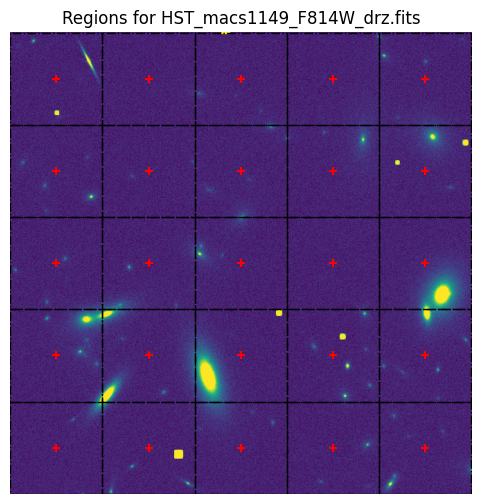

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


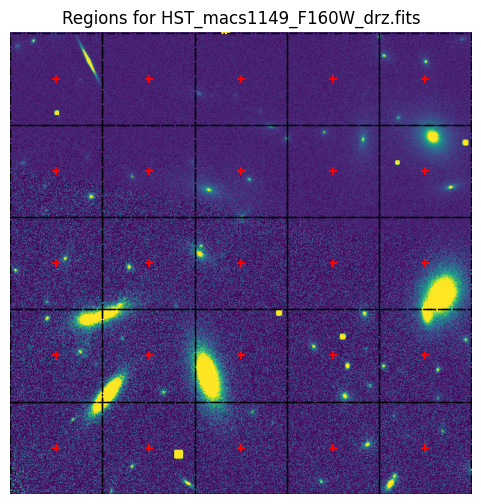

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


In [34]:
# Number of tiles for each side of image.
# This will sub-divide the input images in a 4x4 grid of tiles
number_of_regions_per_side = 5

# The path where region images will be saved
region_path = target_root_path / 'regions'
if not region_path.is_dir():
    os.makedirs(region_path)



for target_field_name in target_field_names.split(','):
    for waveband in wavebands_list.split(','):
        for suffix in [sci_images_suffix, exp_images_suffix, rms_images_suffix, seg_images_suffix]:
            target_image_file = target_root_path / f"{telescope_name}_{target_field_name}_{waveband}_{suffix}"
            img_data = fits.getdata(target_image_file)
            img_header = fits.getheader(target_image_file)
            img_wcs = WCS(img_header)
            
            img_height, img_width = img_data.shape[:2]
            region_height = img_height // number_of_regions_per_side
            region_width = img_width // number_of_regions_per_side

            region_list = []
            region_index = 0
        
            if suffix == sci_images_suffix:
                ccd_gain = img_header.get('CCDGAIN')
                exp_time = img_header.get('EXPTIME')
                mul_factor = exp_time / ccd_gain
            else:
                mul_factor = 1.0

            if suffix == sci_images_suffix:
                fig, ax = plt.subplots(1, 1, figsize=(6, 6))
            else:
                fig = None
                ax = None
            
            for h in range(number_of_regions_per_side):
                for k in range(number_of_regions_per_side):
                    region_center_x = region_width * (h + 0.5)
                    region_center_y = region_height * (k + 0.5)
                    try:
                        cutout = Cutout2D(
                            data=img_data,
                            position=(region_center_x, region_center_y),
                            size=(region_width, region_height),
                            wcs=img_wcs
                        )
                    except Exception as exc:
                        print(exc)
                        continue

                    if ax:
                        rect = patches.Rectangle(
                            (region_width * h, region_height * k),
                            region_width, region_height,
                            fc='none',
                            ec='black',
                            lw=1.0,
                            ls='-.'
                        )
                        ax.add_patch(rect)
        
                    header = img_header.copy()
                    header.update(cutout.wcs.to_header())
                    data = cutout.data * mul_factor
                    data[~np.isfinite(data)] = 0
        
                    if suffix == sci_images_suffix:
                        region_list.append((region_center_x, region_center_y))
                    hdu = fits.PrimaryHDU(
                        data=data,
                        header=header
                    )
                    region_file_name = f"{telescope_name}_{target_field_name}_{waveband}_{suffix}_reg{h:1d}{k:1d}.fits"
                    hdu.writeto(os.path.join(region_path, region_file_name), overwrite=True)
                    region_index += 1
        
            if suffix == sci_images_suffix:
                vmin=-0.005
                vmax=0.05
            else:
                vmin=None
                vmax=None

            if ax:
                ax.imshow(img_data, vmin=vmin, vmax=vmax, origin='lower')
                ax.axis('off')
                ax.scatter([x[0] for x in region_list], [x[1] for x in region_list], marker='+', c='red')
                ax.set_title(f"Regions for {target_image_file.name}")
                plt.show()
                plt.close(fig)

Prepare the tables for galfit run

In [5]:
mode = 'run' 
tasks = '0>1'
h5pytable_filename = 'table_galfit_on_stamps_run.h5'
wavebands_list = 'F814W,F160W'

# types of psf estimation methods, available are moffat,
# observed, pca, effective(HST only)
psf_image_types_list='moffat_psf,observed_psf,pca_psf'

# types of sigma image generation methods, available are
# custom_sigma_image and internal_generated_sigma_image
sigma_image_types_list='custom_sigma_image,internal_generated_sigma_image'

# types of background estimation methods, available are
# background_free_fit and background_fixed_value
background_estimate_methods_list='background_free_fit,background_fixed_value' 

# factor by which the stamp around the galaxy is enlarged as function
# of the target galaxy effective radius 
enlarging_image_factor=20 

# if a neighbouring galaxy is closer to the target than this factor times
# the target galaxy effective radius, then the neighbouring galaxy is
# simultaneously fit
enlarging_separation_factor=10

convolution_box_size=256

source_galaxies_catalogue_suffix='multiband_sources.cat'
target_galaxies_catalogue_suffix='multiband_targets.cat'
target_galaxies_id_key='NUMBER'

parameters_table_suffix = 'param_table.fits'

function = 'main'
n_cores = 1

# Same number of tiles per side as defined in the previous cell
number_of_regions_per_side=5

subprocess.run([
    f'{esub_path}',
    main_functions_dir / 'create_table_for_galfit_regions.py',
    f'--mode={mode}', 
    f'--tasks={tasks}',
    f'--root_path={root_path}',
    f'--h5pytable_folder={h5pytable_folder}',
    f'--h5pytable_filename={h5pytable_filename}',
    f'--telescope_name={telescope_name}',
    f'--target_field_names={target_field_names}',
    f'--wavebands_list={wavebands_list}',
    f'--psf_image_types_list={psf_image_types_list}',
    f'--sigma_image_types_list={sigma_image_types_list}',
    f'--background_estimate_methods_list={background_estimate_methods_list}',
    f'--number_of_regions_per_side={number_of_regions_per_side}',
    f'--pixel_scale={pixel_scale}',
    f'--convolution_box_size={convolution_box_size}',
    f'--galfit_binary_file={galfit_binary_path}',
    f'--source_galaxies_catalogue_suffix={target_galaxies_catalogue_suffix}',
    f'--parameters_table_suffix={parameters_table_suffix}',
    f'--sci_images_suffix={sci_images_suffix}',
    f'--rms_images_suffix={rms_images_suffix}',
    f'--exp_images_suffix={exp_images_suffix}',
    f'--seg_images_suffix={seg_images_suffix}',
    f'--function={function}',
    f'--n_cores={n_cores}'
])

/home/daddona/venvs/morphofit/lib/python3.14/site-packages/ekit/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


2026-05-25 10:42:47,561 -      esub.py: 435 - WARNING - DEPRECATION WARNING: The n_cores option will be dropped in a future version. Use n_jobs instead.
 
                   ______   
________________  ____  /_  
_  _ \_  ___/  / / /_  __ \ 
/  __/(__  )/ /_/ /_  /_/ / 
\___//____/ \__,_/ /_.___/  
 
2026-05-25 10:42:47,562 -      esub.py: 518 -    INFO - Running in run mode run
2026-05-25 10:42:48,652 -      esub.py: 555 -    INFO - Running setup function from executable
2026-05-25 10:42:48,652 -      esub.py: 632 -    INFO - Running locally!
2026-05-25 10:42:48,652 -      esub.py: 646 -    INFO - Running on tasks: [0]
2026-05-25 10:42:48,652 -      esub.py: 650 -    INFO - Running function main
26-05-25 10:42:49 create_tab INF   Number of combinations: 600 
2026-05-25 10:42:49,286 -      esub.py: 709 -    INFO - ##################### Starting Task 0 #####################
2026-05-25 10:42:49,293 -      esub.py: 714 -    INFO - ##################### Finished Task 0 ####################

CompletedProcess(args=['/home/daddona/venvs/morphofit/bin/esub', PosixPath('/home/daddona/morphofit-daddona/main_functions/create_table_for_galfit_regions.py'), '--mode=run', '--tasks=0>1', '--root_path=/home/daddona/morphofit-daddona/examples/demo_data', '--h5pytable_folder=/home/daddona/morphofit-daddona/examples/demo_data/h5table', '--h5pytable_filename=table_galfit_on_stamps_run.h5', '--telescope_name=HST', '--target_field_names=macs1149', '--wavebands_list=F814W,F160W', '--psf_image_types_list=moffat_psf,observed_psf,pca_psf', '--sigma_image_types_list=custom_sigma_image,internal_generated_sigma_image', '--background_estimate_methods_list=background_free_fit,background_fixed_value', '--number_of_regions_per_side=5', '--pixel_scale=0.06', '--convolution_box_size=256', '--galfit_binary_file=/usr/local/bin/galfit', '--source_galaxies_catalogue_suffix=multiband_targets.cat', '--parameters_table_suffix=param_table.fits', '--sci_images_suffix=drz.fits', '--rms_images_suffix=rms.fits', '

Run morphofit on each region

In [10]:
done_region_ids = []

In [15]:
mode = 'run'

files_archive_prefix='galfit_res'
source_galaxies_keys='NUMBER,ALPHAWIN_J2000,DELTAWIN_J2000,MAG_AUTO,FLUX_RADIUS,SERSIC_INDEX,BWIN_IMAGE,AWIN_IMAGE,THETAWIN_SKY,TOFIT,COMPONENT_NUMBER,LIGHT_PROFILE' # keyword names in the sources catalogue for the properties needed by morphofit
display_type_galfit='regular'
galfit_options='0'

# True to save diagnostic plots, False otherwise
diagnostic_plots='True'
local_or_cluster='local'
function = 'main'

n_cores = os.cpu_count()

failed_regions_ids = []

log_dir = root_path / 'logs'
if not log_dir.is_dir():
    os.makedirs(log_dir)

task_list = list(range(number_of_regions_per_side**2))
for j in tqdm(task_list, desc="Running galfit on regions:"):

    if j in failed_regions_ids:
        continue

    if j in done_region_ids:
        continue

    tasks = f'{j}>{j+1}'

    log_file = os.path.join(log_dir, f'log_{j:06d}.txt')
    with open(log_file, "w") as outfile:
        try:
            res = subprocess.run(
                [
                    f'{esub_path}', 
                    main_functions_dir / 'main_galfit_regions.py',
                    f'--mode={mode}', 
                    f'--tasks={tasks}',
                    f'--h5pytable_folder={h5pytable_folder}',
                    f'--h5pytable_filename={h5pytable_filename}',
                    f'--temp_dir_path={root_path.absolute()}',
                    f'--files_archive_prefix={files_archive_prefix}',
                    f'--source_galaxies_keys={source_galaxies_keys}',
                    f'--display_type_galfit={display_type_galfit}',
                    f'--galfit_options={galfit_options}',
                    f'--diagnostic_plots={diagnostic_plots}',
                    f'--phot_apertures={phot_apertures}',
                    f'--local_or_cluster={local_or_cluster}',
                    f'--function={function}', 
                    f'--n_cores={n_cores}'
                ],
                stdout=outfile,
                stderr=outfile,
                timeout=120,
            )
            res.check_returncode()
        except Exception as exc:
            print(exc)
            failed_regions_ids.append(j)
            tmp_dir = os.path.join(root_path, f'tmp_index{j:06d}')
            if os.path.isdir(tmp_dir):
                shutil.rmtree(tmp_dir)
        else:
            done_region_ids.append(j)

print(f"Falid tasks: {len(failed_regions_ids)} [{len(failed_regions_ids)/len(task_list):.2%}]")

with open(os.path.join(root_path, target_field_names, "regions_failed.json"), 'w') as f:
    json.dump(failed_regions_ids, f)

with open(os.path.join(root_path, target_field_names, "regions_done.json"), 'w') as f:
    json.dump(done_region_ids, f)

Running galfit on regions::   0%|          | 0/25 [00:00<?, ?it/s]

Command '['/home/daddona/venvs/morphofit/bin/esub', PosixPath('/home/daddona/morphofit-daddona/main_functions/main_galfit_regions.py'), '--mode=run', '--tasks=0>1', '--h5pytable_folder=/home/daddona/morphofit-daddona/examples/demo_data/h5table', '--h5pytable_filename=table_galfit_on_stamps_run.h5', '--temp_dir_path=/home/daddona/morphofit-daddona/examples/demo_data', '--files_archive_prefix=galfit_res', '--source_galaxies_keys=NUMBER,ALPHAWIN_J2000,DELTAWIN_J2000,MAG_AUTO,FLUX_RADIUS,SERSIC_INDEX,BWIN_IMAGE,AWIN_IMAGE,THETAWIN_SKY,TOFIT,COMPONENT_NUMBER,LIGHT_PROFILE', '--display_type_galfit=regular', '--galfit_options=0', '--diagnostic_plots=True', '--phot_apertures=3,5,8,10,13,15,18,20,23,25,28,30', '--local_or_cluster=local', '--function=main', '--n_cores=16']' returned non-zero exit status 1.
Command '['/home/daddona/venvs/morphofit/bin/esub', PosixPath('/home/daddona/morphofit-daddona/main_functions/main_galfit_regions.py'), '--mode=run', '--tasks=1>2', '--h5pytable_folder=/home/d

Render Galfit models on Regions